# Credit Card Fraud Detection using Artificial Neural Networks

## 0. Introduktion

Kreditkortsbedrägerier är ett stort problem för banker och företag världen över och orsakar stora ekonomiska förluster varje år.

Målet med detta projekt är att bygga en Artificial Neural Network (ANN)-modell som kan identifiera bedrägliga transaktioner baserat på historisk transaktionsdata.

Genom att använda maskininlärning och deep learning kan banker automatisera fraud detection, minska ekonomiska risker och förbättra säkerheten för kunder.

I projektet kommer vi att:
- utföra Exploratory Data Analysis (EDA)
- analysera relationer mellan variabler
- bygga och träna en ANN-modell
- utvärdera modellens prestanda
- testa förbättringar och optimeringar

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import Dense, Dropout

from imblearn.over_sampling import SMOTE

In [2]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 2. Dataset & Översikt

| Egenskap | Värde |
|---|---|
| Antal transaktioner | 284,807 |
| Antal variabler | 31 |
| Fraud cases | 492 |
| Normala transaktioner | 284,315 |

Datasetet innehåller kreditkortstransaktioner där målet är att identifiera vilka transaktioner som är bedrägliga.

Variablerna har anonymiserats och transformerats med PCA. Datasetet innehåller inga saknade värden.

Target-variabeln:
- Class = 0 → normal transaktion
- Class = 1 → bedräglig transaktion

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. EDA - Exploratory Data Analysis

Datasetet är mycket obalanserat eftersom antalet bedrägliga transaktioner är betydligt mindre än antalet normala transaktioner.

De flesta transaktioner har relativt låga belopp medan ett mindre antal transaktioner har mycket höga värden.

Korrelationsmatrisen visar främst svaga linjära samband mellan variablerna, vilket är förväntat eftersom variablerna är PCA-transformerade.

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

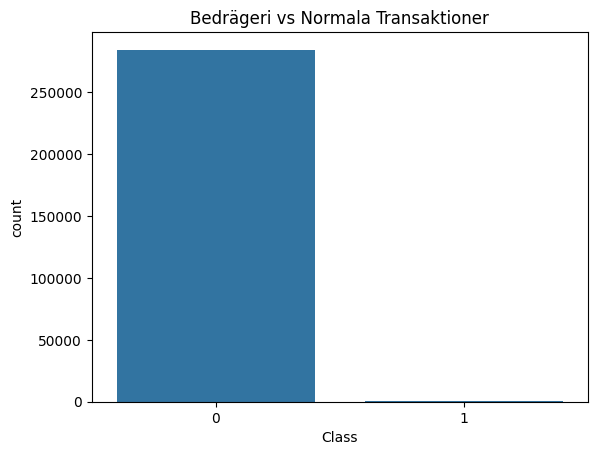

In [8]:
sns.countplot(x='Class', data=df)

plt.title("Bedrägeri vs Normala Transaktioner")

plt.show()

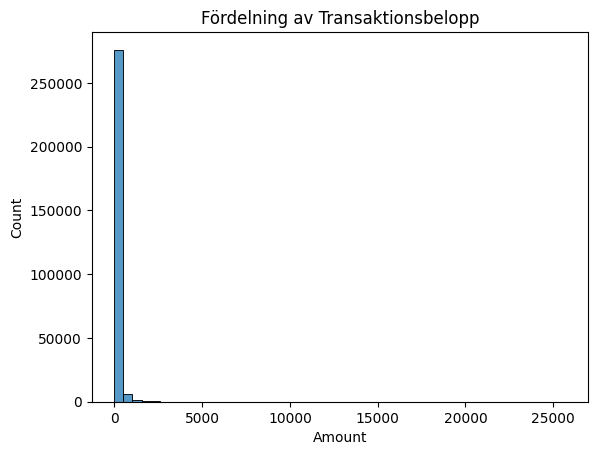

In [9]:
sns.histplot(df['Amount'], bins=50)

plt.title("Fördelning av Transaktionsbelopp")

plt.show()

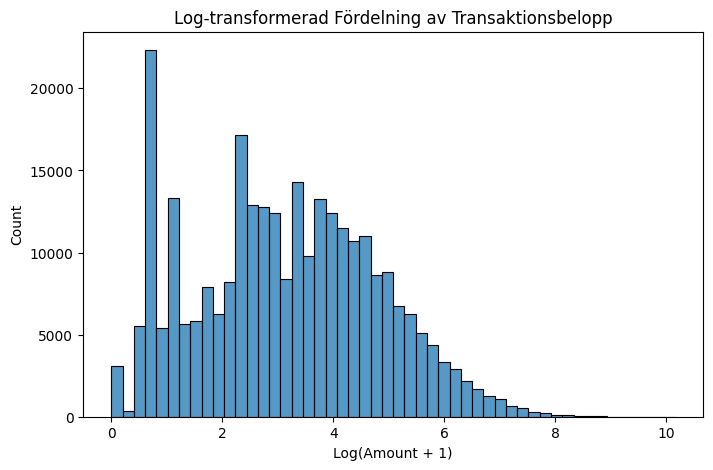

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['Amount']), bins=50)

plt.title("Log-transformerad Fördelning av Transaktionsbelopp")

plt.xlabel("Log(Amount + 1)")

plt.show()

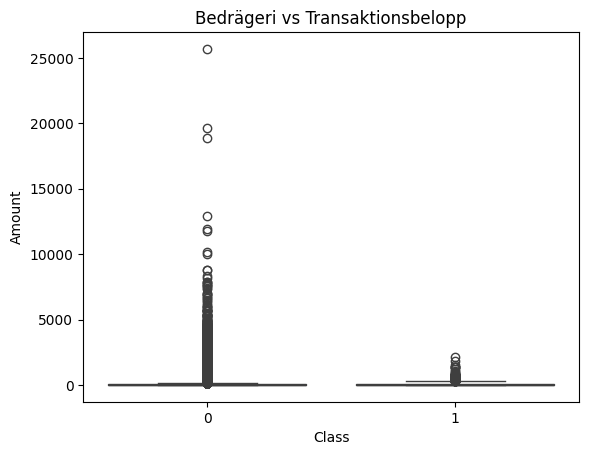

In [11]:
sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Bedrägeri vs Transaktionsbelopp")

plt.show()

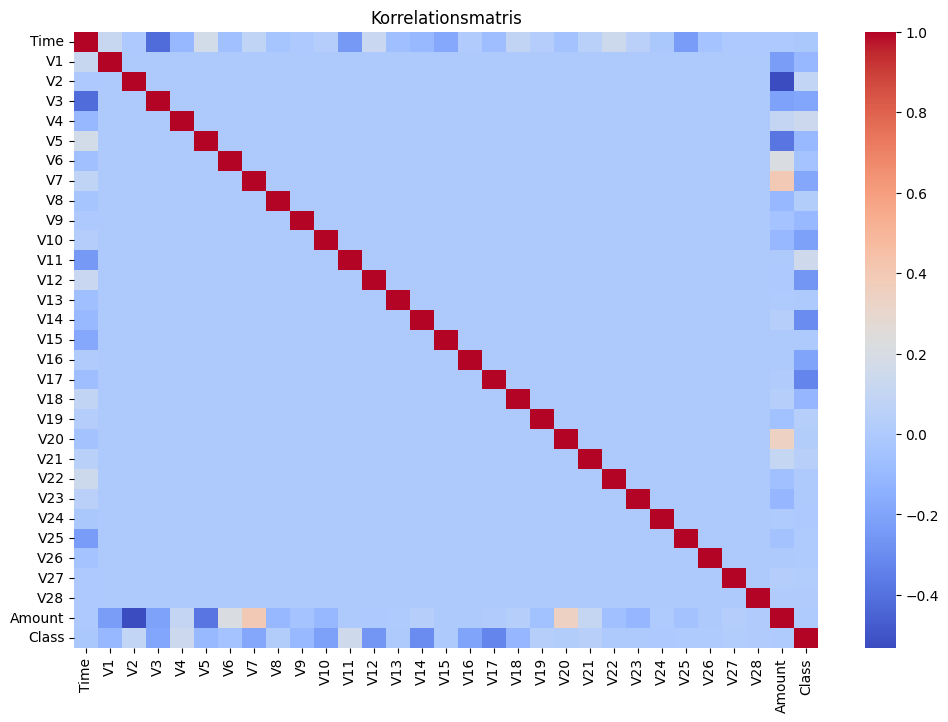

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Korrelationsmatris")

plt.show()

## 4. Datarensning & Preprocessing

Innan modellen kan tränas behöver datan förberedas.

I detta steg:
- delar vi upp datan i features och target
- skapar tränings- och testdata
- skalar variablerna med StandardScaler

Skalning är viktigt för neurala nätverk eftersom variabler med olika skalor annars kan påverka modellens träning negativt.

### 4.1 Features och Target

In [13]:
X = df.drop('Class', axis=1)
y = df['Class']

### 4.2 Train/Test Split
Datasetet delas upp i träningsdata och testdata.

- Träningsdata används för att träna modellen
- Testdata används för att utvärdera modellens prestanda

`stratify=y` används för att behålla samma klassfördelning i båda dataseten eftersom datan är obalanserad.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.3 Skalning av Data
Eftersom ANN-modeller är känsliga för skillnader i skala används StandardScaler för att normalisera datan.

Detta hjälper modellen att träna stabilare och snabbare.

In [15]:
# Spara originaldata innan scaling för senare experiment

X_train_original = X_train.copy()
X_test_original = X_test.copy()

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Bygg och Konfigurera ANN-modellen

I detta steg bygger vi en Artificial Neural Network (ANN)-modell för att identifiera bedrägliga transaktioner.

Modellen består av:
- ett inputlager
- två dolda lager
- ett outputlager

ReLU används som aktiveringsfunktion i de dolda lagren och sigmoid används i output-lagret eftersom detta är ett binärt klassificeringsproblem.

### 5.1 Skapa modellen

In [17]:

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 5.2 Kompilera modellen
Modellen kompileras med:
- Adam optimeringsalgoritm
- binary_crossentropy som loss function (vi har två klasser)
- accuracy som utvärderingsmått

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 5.3 Modellöversikt
`model.summary()` visar modellens arkitektur, antal lager och antal träningsbara parametrar.

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Träna Modellen

Modellen tränas på träningsdatan för att lära sig identifiera mönster mellan normala och bedrägliga transaktioner.

Under träningen uppdateras modellens vikter genom backpropagation och gradient descent för att minska modellens loss function

### 6.1 Träna modellen

### OBS
Kör inte om träningscellerna efter att slutresultaten sparats eftersom ANN-modeller kan ge något varierande resultat mellan körningar.

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 335us/step - accuracy: 0.9987 - loss: 0.0089 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 2/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 330us/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 3/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 331us/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 4/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9992 - val_loss: 0.0034
Epoch 5/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 326us/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9993 - val_loss: 0.0032


### 6.2 Visualisera träningsprocessen

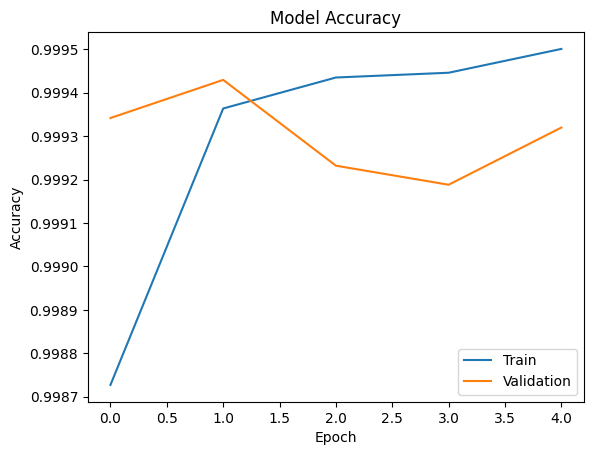

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

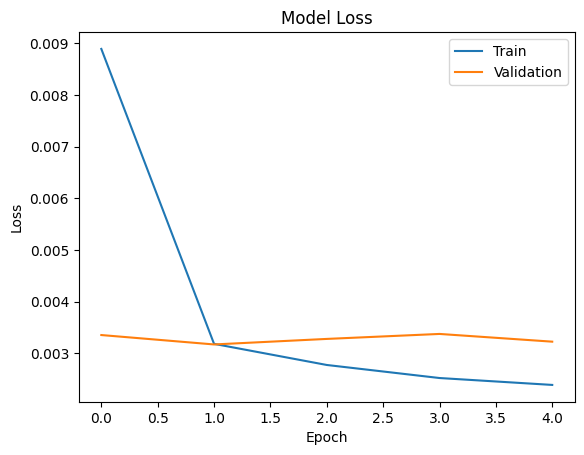

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

### 6.3 Tolkning

Accuracy ökade under träningen samtidigt som loss minskade, vilket visar att modellen lärde sig från datan.

Validation accuracy och validation loss förblev stabila under träningen, vilket tyder på att modellen generaliserar relativt bra på ny data utan tydliga tecken på kraftig overfitting.

## 7. Utvärdera modellen

I detta steg utvärderas modellens prestanda på testdatan.

Eftersom datasetet är obalanserat räcker det inte att endast analysera accuracy. Därför används även:
- precision
- recall
- ROC-AUC
- confusion matrix


### 7.1 Skapa Prediktioner

In [23]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 155us/step


### 7.2 Accuracy
Accuracy visar hur stor andel av modellens prediktioner som var korrekta.

In [24]:
accuracy_score(y_test, y_pred)

0.9992275552122467

### 7.3 Precision
Precision visar hur många av de transaktioner som modellen klassificerade som bedrägerier som faktiskt var bedrägerier.

In [25]:
precision_score(y_test, y_pred)

0.7454545454545455

### 7.4 Recall
Recall är mycket viktigt inom fraud detection eftersom det mäter hur många faktiska bedrägerier modellen lyckades identifiera.

Ett högt recall-värde innebär att modellen missar färre bedrägliga transaktioner.

In [26]:
recall_score(y_test, y_pred)

0.8367346938775511

### 7.5 Classification Report
Classification Report sammanfattar modellens precision, recall och F1-score.

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.84      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



### 7.6 ROC-AUC

ROC-AUC används för att mäta modellens förmåga att skilja mellan normala och bedrägliga transaktioner.

Ett högre ROC-AUC-värde innebär bättre klassificeringsförmåga.

In [28]:
roc_auc_score(y_test, y_pred_prob)

0.9696059628128122

### 7.7 Confusion Matrix

Confusion Matrix visar:
- korrekta klassificeringar
- felklassificeringar
- false positives
- false negatives

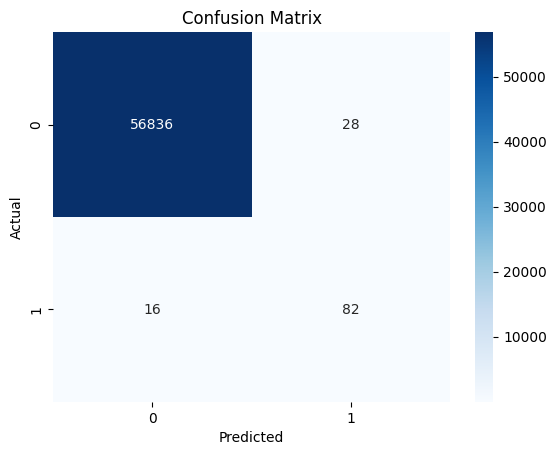

In [29]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 7.8 ROC-kurva
ROC-kurvan visualiserar relationen mellan:
- True Positive Rate
- False Positive Rate

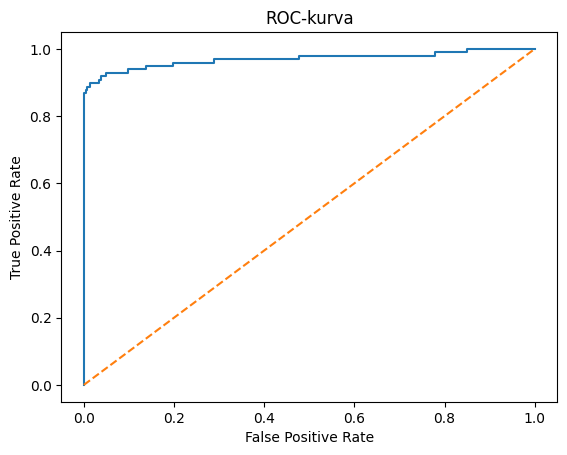

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-kurva")

plt.show()

### 7.9 Tolkning

Modellen uppnådde mycket hög accuracy, men eftersom datasetet är obalanserat är recall och ROC-AUC viktigare mått.

Recall-värdet visar att modellen lyckades identifiera cirka 84 % av de bedrägliga transaktionerna. Ett högre recall-värde innebär samtidigt risk för fler false positives, vilket kan leda till att legitima transaktioner flaggas som misstänkta.

F1-score används för att balansera precision och recall.

Confusion Matrix visar att modellen missade relativt få fraud cases samtidigt som antalet false positives förblev lågt.

ROC-AUC-värdet visar att modellen hade mycket god förmåga att skilja mellan normala och bedrägliga transaktioner.

Resultaten visar att ANN-modellen fungerar effektivt för fraud detection och kan bidra till att minska ekonomiska förluster för banker och företag.

## 8. Förbättringar & Extra

För att förbättra modellens prestanda testades olika ANN-arkitekturer och regulariseringsstrategier.

Målet var att undersöka om modellen kunde generalisera bättre och minska risken för overfitting.

### 8.1 Modell med Dropout
Dropout används som regulariseringsteknik för att minska overfitting genom att slumpmässigt inaktivera neuroner under träningen.

In [31]:
model2 = Sequential()

model2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dropout(0.3))

model2.add(Dense(32, activation='relu'))
model2.add(Dropout(0.3))

model2.add(Dense(1, activation='sigmoid'))

/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 8.2 Kompilera modellen

In [32]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 8.3 Träna modellen

### OBS
Kör inte om träningscellerna efter att slutresultaten sparats eftersom ANN-modeller kan ge något varierande resultat mellan körningar.

In [33]:
history2 = model2.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 364us/step - accuracy: 0.9978 - loss: 0.0111 - val_accuracy: 0.9993 - val_loss: 0.0036
Epoch 2/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 352us/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 3/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 366us/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9993 - val_loss: 0.0032
Epoch 4/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 367us/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9995 - val_loss: 0.0033
Epoch 5/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 378us/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0031


### 8.4 Utvärdera den förbättrade modellen

In [34]:
y_pred_prob2 = model2.predict(X_test)

y_pred2 = (y_pred_prob2 > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 172us/step


### 8.5 Modell med Class Weights

Eftersom datasetet är mycket obalanserat användes class weights för att ge större betydelse åt bedrägliga transaktioner under träningen.

Detta hjälper modellen att fokusera mer på den underrepresenterade fraud-klassen.

In [35]:
tf.keras.backend.clear_session()

In [36]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

class_weights

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}

In [37]:
model3 = Sequential()

model3.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### OBS
Kör inte om träningscellerna efter att slutresultaten sparats eftersom ANN-modeller kan ge något varierande resultat mellan körningar.

In [39]:
history3 = model3.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 358us/step - accuracy: 0.9821 - loss: 0.2225 - val_accuracy: 0.9652 - val_loss: 0.1531
Epoch 2/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - accuracy: 0.9777 - loss: 0.1446 - val_accuracy: 0.9568 - val_loss: 0.1494
Epoch 3/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 323us/step - accuracy: 0.9797 - loss: 0.1153 - val_accuracy: 0.9484 - val_loss: 0.1537
Epoch 4/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - accuracy: 0.9798 - loss: 0.0957 - val_accuracy: 0.9605 - val_loss: 0.1202
Epoch 5/5
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 2s 318us/step - accuracy: 0.9809 - loss: 0.0841 - val_accuracy: 0.9484 - val_loss: 0.1454


In [40]:
y_pred_prob3 = model3.predict(X_test)

y_pred3 = (y_pred_prob3 > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step


### 8.6 Modell med SMOTE

SMOTE (Synthetic Minority Oversampling Technique) användes för att hantera den obalanserade datan genom att skapa syntetiska exempel av den underrepresenterade fraud-klassen.

För detta experiment skapades en separat preprocessing-pipeline där SMOTE applicerades på träningsdatan innan modellträning.

In [41]:
tf.keras.backend.clear_session()

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_original,
    y_train
)

In [42]:
scaler_smote = StandardScaler()

X_train_smote = scaler_smote.fit_transform(X_train_smote)

X_test_smote = scaler_smote.transform(X_test_original)

In [43]:
model4 = Sequential()

model4.add(Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)))

model4.add(Dense(16, activation='relu'))

model4.add(Dense(1, activation='sigmoid'))

/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### OBS
Kör inte om träningscellerna efter att slutresultaten sparats eftersom ANN-modeller kan ge något varierande resultat mellan körningar.


In [45]:
history4 = model4.fit(
    X_train_smote,
    y_train_smote,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 316us/step - accuracy: 0.9884 - loss: 0.0338 - val_accuracy: 0.9969 - val_loss: 0.0092
Epoch 2/5
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 311us/step - accuracy: 0.9967 - loss: 0.0105 - val_accuracy: 0.9992 - val_loss: 0.0038
Epoch 3/5
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 312us/step - accuracy: 0.9977 - loss: 0.0076 - val_accuracy: 0.9990 - val_loss: 0.0038
Epoch 4/5
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 310us/step - accuracy: 0.9982 - loss: 0.0059 - val_accuracy: 0.9991 - val_loss: 0.0029
Epoch 5/5
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 310us/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9999 - val_loss: 0.0012


In [46]:
y_pred_prob4 = model4.predict(X_test_smote)

y_pred4 = (y_pred_prob4 > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step


### 8.7 Jämförelse mellan modeller
Modellen med class weights presterade bäst när det gäller recall och lyckades identifiera cirka 92 % av de bedrägliga transaktionerna.

Detta visar att class weights hjälpte modellen att fokusera mer på den underrepresenterade fraud-klassen.

ROC-AUC minskade något jämfört med de andra modellerna, men recall förbättrades tydligt, vilket är särskilt viktigt inom fraud detection eftersom målet är att missa så få bedrägerier som möjligt.

Resultaten visar att hantering av obalanserad data är mycket viktigt för att förbättra modellens prestanda.

Modellen med Class Weights gav bäst resultat och uppnådde högst recall samtidigt som ROC-AUC förblev mycket hög.

Detta visar att class weights var den mest effektiva strategin för att hantera den obalanserade datan i detta projekt.

In [47]:
comparison = pd.DataFrame({
    'Modell': [
        'Enkel ANN',
        'ANN med Dropout',
        'ANN med Class Weights',
        'ANN med SMOTE'
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred2),
        recall_score(y_test, y_pred3),
        recall_score(y_test, y_pred4)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_prob),
        roc_auc_score(y_test, y_pred_prob2),
        roc_auc_score(y_test, y_pred_prob3),
        roc_auc_score(y_test, y_pred_prob4)
    ]
})

comparison

,Modell,Recall,ROC-AUC
0,Enkel ANN,0.836735,0.969606
1,ANN med Dropout,0.816327,0.976813
2,ANN med Class Weights,0.918367,0.973843
3,ANN med SMOTE,0.836735,0.967699


## 9. Slutsats

Syftet med projektet var att bygga en ANN-modell för att identifiera bedrägliga kreditkortstransaktioner.

Genom Exploratory Data Analysis (EDA) analyserades datasetets struktur, relationer mellan variabler och den stora obalansen mellan normala och bedrägliga transaktioner.

Resultaten visade att ANN-modeller presterade mycket bra för identifiering av bedrägerier, särskilt efter användning av class weights för att hantera den obalanserade datan.

Flera modeller testades och jämfördes, inklusive:
- enkel ANN
- ANN med Dropout
- ANN med Class Weights
- ANN med SMOTE

Den bästa modellen var ANN med Class Weights, som uppnådde högst recall och kunde identifiera cirka 92 % av de bedrägliga transaktionerna.

SMOTE förbättrade inte resultaten lika mycket i detta projekt, vilket visar att olika balanseringstekniker påverkar modeller på olika sätt.

Projektet visar hur Artificial Neural Networks kan användas inom finans och säkerhet för att:
- minska ekonomiska förluster
- förbättra fraud detection
- automatisera övervakning av transaktioner
- öka kundernas säkerhet